In [30]:
import matplotlib.pyplot as plt

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})


In [31]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.spike_detection import *
from utils.preprocess_neural import *

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import numpy.ma as ma
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import subprocess
import shutil
import pickle

%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
main_data_folder = '../data/CKII_pAce38_PX_20251126'
FOV_image_folder = '/Volumes/QixinT9/AdamLab/Data/Freely_moving_raw_data/pAce38_PX_2025_11_26'




In [33]:
# # This is how you load the data later

# merged_data_path_CS = os.path.join(main_data_folder, 'merged_aligned_data_CS.pkl')
# with open(merged_data_path_CS, 'rb') as f:
#     loaded_merged_data_CS = pickle.load(f)
#     traces = loaded_merged_data_CS['traces']
#     spikes = loaded_merged_data_CS['spikes']
#     speed = loaded_merged_data_CS['speed']
#     ts_neural = loaded_merged_data_CS['ts_neural']
#     x_neural = loaded_merged_data_CS['x_neural']
#     y_neural = loaded_merged_data_CS['y_neural']
#     hd_angles_neural = loaded_merged_data_CS['hd_angles_neural']
#     weights_all = loaded_merged_data_CS['weights_all']
#     ROIs_all = loaded_merged_data_CS['ROIs_all']
#     mean_images = loaded_merged_data_CS['mean_images']
#     mean_images_raw = loaded_merged_data_CS['mean_images_raw']
#     frame_rate = loaded_merged_data_CS['frame_rate']
#     frame_width = loaded_merged_data_CS['frame_width']
#     frame_height = loaded_merged_data_CS['frame_height']
#     subfolders = loaded_merged_data_CS['subfolders']
#     complex_bursts_dicts = loaded_merged_data_CS['complex_bursts_dicts']
#     refined_SS = loaded_merged_data_CS['refined_SS']
#     all_CS_spikes = loaded_merged_data_CS['all_CS_spikes']
#     all_spikes = loaded_merged_data_CS['all_spikes']
#     spike_heights_interpolated = loaded_merged_data_CS['spike_heights_interpolated']
#     SNR_interpolated = loaded_merged_data_CS['SNR_interpolated']    
#     traces_SNR_interpolated = loaded_merged_data_CS['traces_SNR_interpolated']
#     Vm_SNR_interpolated = loaded_merged_data_CS['Vm_SNR_interpolated']
#     # CS_detection_params = loaded_merged_data_CS['CS_detection_params']
#     # pnorm_CS = CS_detection_params['pnorm_CS']
#     # pnorm_SS = CS_detection_params['pnorm_SS']
#     # process_window_CS = CS_detection_params['process_window_CS']
#     # process_window_SS = CS_detection_params['process_window_SS']
#     # complex_spike_threshold = CS_detection_params['complex_spike_threshold']
# print(f"Loaded data from {merged_data_path_CS}")
# Vms = Vm_SNR_interpolated
# traces = np.array(traces_SNR_interpolated)
# frame_rate = frame_rate

In [34]:
# # Optional: Remove bad SNR segments
# spikes = all_spikes.copy()
# #traces = traces_SNR_interpolated
# #Vms = Vm_SNR_interpolated

# SNR_threshold = 3.5
# bad_masks = []

# # Now for each cell: remove spikes and make traces and Vms NaN where its SNR_interpolated < SNR_threshold
# for cell_idx in range(len(spikes)):
#     snr_vals = np.asarray(SNR_interpolated[cell_idx])
#     if snr_vals.ndim == 0:
#         continue
#     bad_mask = snr_vals < SNR_threshold
#     bad_masks.append(bad_mask)
#     if not np.any(bad_mask):
#         continue

#     #traces[cell_idx][bad_mask] = np.nan
#     #Vms[cell_idx][bad_mask] = np.nan

#     def _filter_spikes(spk_arr, bad_mask_local):
#         spk_arr = np.asarray(spk_arr, dtype=np.int64)
#         if spk_arr.size == 0:
#             return spk_arr
#         spk_arr = spk_arr[(spk_arr >= 0) & (spk_arr < bad_mask_local.shape[0])]
#         return spk_arr[~bad_mask_local[spk_arr]]

#     spikes[cell_idx] = _filter_spikes(spikes[cell_idx], bad_mask)
#     all_CS_spikes[cell_idx] = _filter_spikes(all_CS_spikes[cell_idx], bad_mask)
#     refined_SS[cell_idx] = _filter_spikes(refined_SS[cell_idx], bad_mask)

#     print(f'Cell {cell_idx}: removed {np.sum(bad_mask)} bad SNR frames, spikes reduced from {len(loaded_merged_data_CS["all_spikes"][cell_idx])} to {len(spikes[cell_idx])}')

# bad_masks = np.array(bad_masks)

In [35]:
# load merged data 

merged_data_path_CS = os.path.join(main_data_folder, 'merged_aligned_data.pkl')
with open(merged_data_path_CS, 'rb') as f:
    loaded_merged_data_CS = pickle.load(f)
    traces = loaded_merged_data_CS['traces']
    spikes = loaded_merged_data_CS['spikes']
    speed = loaded_merged_data_CS['speed']
    ts_neural = loaded_merged_data_CS['ts_neural']
    x_neural = loaded_merged_data_CS['x_neural']
    y_neural = loaded_merged_data_CS['y_neural']
    hd_angles_neural = loaded_merged_data_CS['hd_angles_neural']
    frame_rate = loaded_merged_data_CS['frame_rate']
    frame_width = loaded_merged_data_CS['frame_width']
    frame_height = loaded_merged_data_CS['frame_height']
    subfolders = loaded_merged_data_CS['subfolders']
    complex_bursts_dicts = loaded_merged_data_CS['complex_bursts_dicts']
    refined_SS = loaded_merged_data_CS['refined_SS']
    all_CS_spikes = loaded_merged_data_CS['all_CS_spikes']
    all_spikes = loaded_merged_data_CS['all_spikes']
    spike_heights_interpolated = loaded_merged_data_CS['spike_heights_interpolated']
    SNR_interpolated = loaded_merged_data_CS['SNR_interpolated']    
    session_start_frames = loaded_merged_data_CS['session_start_frames']
    traces_SNR_interpolated = loaded_merged_data_CS['traces_SNR_interpolated']
    Vm_SNR_interpolated = loaded_merged_data_CS['Vm_SNR_interpolated']
    burst_metrics = loaded_merged_data_CS['burst_metrics']
    plateaus_dicts = loaded_merged_data_CS.get('plateaus_dicts', None)

    weights_all = loaded_merged_data_CS['weights_all']
    ROIs_all = loaded_merged_data_CS['ROIs_all']
    mean_images = loaded_merged_data_CS['mean_images']
    mean_images_raw = loaded_merged_data_CS['mean_images_raw']
    frame_rate = loaded_merged_data_CS['frame_rate']
    frame_width = loaded_merged_data_CS['frame_width']
    frame_height = loaded_merged_data_CS['frame_height']

print(f"Loaded data from {merged_data_path_CS}")
if plateaus_dicts is not None:
    print(f"Loaded plateaus_dicts for {len(plateaus_dicts)} cells")
else:
    print("No plateaus_dicts found in merged data")


sampling_rate = frame_rate


Loaded data from ../data/CKII_pAce38_PX_20251126/merged_aligned_data.pkl
Loaded plateaus_dicts for 9 cells


In [36]:
# Optional: Remove bad SNR segments
spikes = all_spikes.copy()
#traces = traces_SNR_interpolated
#Vms = Vm_SNR_interpolated

SNR_threshold = 3.5
bad_masks = []

# Now for each cell: remove spikes and make traces and Vms NaN where its SNR_interpolated < SNR_threshold
for cell_idx in range(len(spikes)):
    snr_vals = np.asarray(SNR_interpolated[cell_idx])
    if snr_vals.ndim == 0:
        continue
    bad_mask = snr_vals < SNR_threshold
    bad_masks.append(bad_mask)
    if not np.any(bad_mask):
        continue

    #traces[cell_idx][bad_mask] = np.nan
    #Vms[cell_idx][bad_mask] = np.nan

    def _filter_spikes(spk_arr, bad_mask_local):
        spk_arr = np.asarray(spk_arr, dtype=np.int64)
        if spk_arr.size == 0:
            return spk_arr
        spk_arr = spk_arr[(spk_arr >= 0) & (spk_arr < bad_mask_local.shape[0])]
        return spk_arr[~bad_mask_local[spk_arr]]

    spikes[cell_idx] = _filter_spikes(spikes[cell_idx], bad_mask)
    all_CS_spikes[cell_idx] = _filter_spikes(all_CS_spikes[cell_idx], bad_mask)
    refined_SS[cell_idx] = _filter_spikes(refined_SS[cell_idx], bad_mask)

    print(f'Cell {cell_idx}: removed {np.sum(bad_mask)} bad SNR frames, spikes reduced from {len(loaded_merged_data_CS["all_spikes"][cell_idx])} to {len(spikes[cell_idx])}')

bad_masks = np.array(bad_masks)

Cell 7: removed 596682 bad SNR frames, spikes reduced from 2472 to 0


In [37]:
# median filter the traces for better visualization
from scipy.signal import medfilt

Vms = []
for cell_idx in range(len(traces)):
    trend = medfilt(traces[cell_idx], kernel_size=501)
    traces[cell_idx] = traces[cell_idx] - trend
    Vms_temp = medfilt(traces[cell_idx], kernel_size=51)
    Vms.append(Vms_temp)

In [38]:
# ######### For pAce21 ##########
# WF_image_name = 'WF-pre-imaging_003.tif'
# WF_image_path = os.path.join(os.path.dirname(main_data_folder), WF_image_name)
# WF_image = plt.imread(WF_image_path)

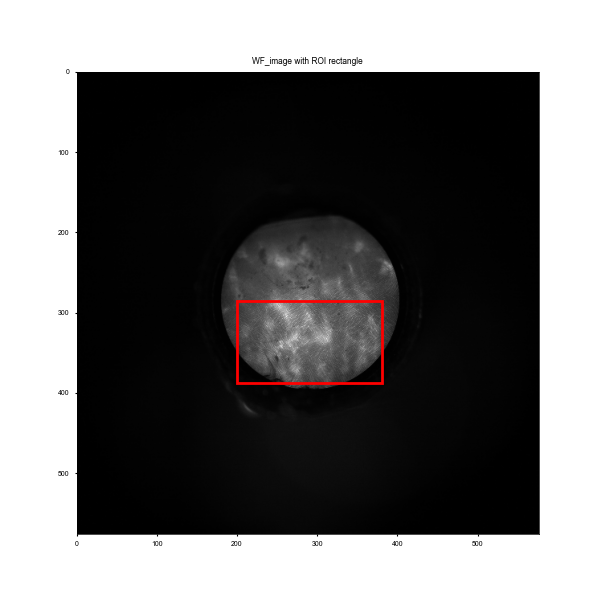

In [39]:
########## For pAce38 ##########
WF_image_name = 'WF_001.tif'
WF_image_path = os.path.join(FOV_image_folder, WF_image_name)
WF_image = plt.imread(WF_image_path)
def downsample_mean(img, factor=2):
    H, W = img.shape
    H2 = (H // factor) * factor
    W2 = (W // factor) * factor

    img = img[:H2, :W2]
    return img.reshape(H2//factor, factor, W2//factor, factor).mean(axis=(1, 3))

WF_image = downsample_mean(WF_image, factor=2)
# Rectangle coordinates (continuous)
xmin = 200.4001671212
ymin = 285.987663366675
xmax = 380.916182389346
ymax = 387.961061388352

width  = xmax - xmin
height = ymax - ymin
import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the image
ax.imshow(WF_image, cmap='gray', origin='upper')

# Add rectangle
rect = patches.Rectangle(
    (xmin, ymin),          # (x, y) = (col, row)
    width,
    height,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
ax.add_patch(rect)

ax.set_title("WF_image with ROI rectangle")
ax.set_xlim(0, WF_image.shape[1])
ax.set_ylim(WF_image.shape[0], 0)  # keep image coordinates consistent
ax.set_aspect('equal')

plt.show()

x0 = int(np.floor(xmin))
x1 = int(np.ceil(xmax)) - 1
y0 = int(np.floor(ymin))
y1 = int(np.ceil(ymax)) - 1

# Clip to image bounds
H, W = WF_image.shape
x0 = max(0, min(W, x0))
x1 = max(0, min(W, x1))
y0 = max(0, min(H, y0))
y1 = max(0, min(H, y1))
WF_image = WF_image[y0:y1, x0:x1]

In [40]:
mean_image1 = mean_images_raw[0]
mean_image2 = mean_images[0]
ROIs = ROIs_all[0]

# Plot

Figure saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/neural_data_summary_figure_v5.svg


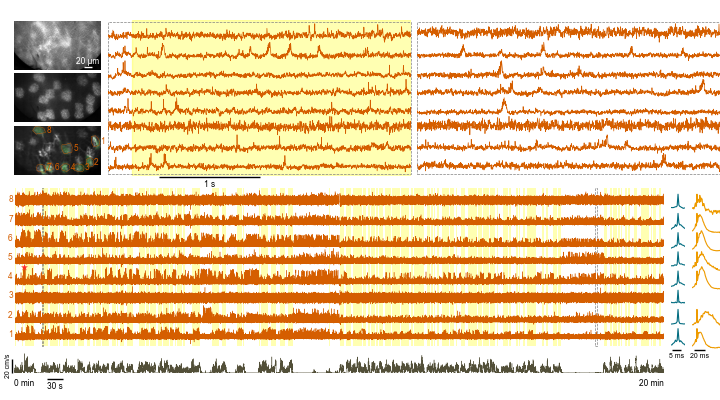

In [41]:
# Version 5: spike shapes with simple spikes (teal) and complex bursts (orange) overlaid
# Same as v4 but with SS/CS spike shape separation

# Define zoom windows for subplots 4 and 5
zoom_window = 3  # seconds
zoom1_start = 50.0  # seconds
zoom2_start = 1069.13 # seconds
exclude_heavily_masked_cells = True

# Movement epoch parameters
speed_threshold = 3  # cm/s
min_duration_s = 0.25
merge_gap_s = 1
kernel_size = 51

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from utils.GRC_helpers import _compute_moving_epochs

# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'

# Single color for all cells
trace_color = '#D55E00'

# Create figure
fig = plt.figure(figsize=(7.2, 4))

# Create GridSpec: 2 rows for main layout
gs = gridspec.GridSpec(2, 16, height_ratios=[1.5, 2], width_ratios=[1]*14 + [0.35, 0.7], hspace=0.05, wspace=0.2)

# Create nested GridSpec for the 3 stacked images (in top-left area)
gs_images = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0, 0:2], hspace=0.05)
ax1 = fig.add_subplot(gs_images[0])  # WF_image (top)
ax2 = fig.add_subplot(gs_images[1])  # mean_image1 (middle)
ax3 = fig.add_subplot(gs_images[2])  # mean_image2 (bottom)

# Top row trace subplots - use nested GridSpec to ensure equal width
gs_traces_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0, 2:16], wspace=0.02)
ax4 = fig.add_subplot(gs_traces_top[0, 0])  # zoomed traces 1 (left half)
ax5 = fig.add_subplot(gs_traces_top[0, 1])  # zoomed traces 2 (right half)

# Bottom row subplot
ax6 = fig.add_subplot(gs[1, :14])    # traces (full width)
ax7_ss = fig.add_subplot(gs[1, 14])  # simple spike shapes (narrow)
ax7_cb = fig.add_subplot(gs[1, 15], sharey=ax7_ss)  # complex burst shapes (wider)

# Compute moving epochs
speed_smooth, moving_epochs, moving_idx = _compute_moving_epochs(
    speed, frame_rate,
    kernel_size=kernel_size, filter_type="boxcar",
    speed_threshold=speed_threshold,
    min_duration_s=min_duration_s, merge_gap_s=merge_gap_s
)

# Get weights and ROIs from first session
weights = weights_all[0]
ROIs = ROIs_all[0]

time_axis = np.arange(traces.shape[1]) / sampling_rate
total_cells = traces.shape[0]
display_exclude_threshold = 0.8


def _get_cell_bad_mask(cell_idx):
    if 'bad_masks' in globals() and bad_masks is not None:
        try:
            if len(bad_masks) == total_cells and cell_idx < len(bad_masks):
                cell_mask = np.asarray(bad_masks[cell_idx], dtype=bool)
                if cell_mask.ndim == 1 and cell_mask.size == len(time_axis):
                    return cell_mask
        except TypeError:
            pass
    if 'SNR_interpolated' in globals() and 'SNR_threshold' in globals() and cell_idx < len(SNR_interpolated):
        snr_vals = np.asarray(SNR_interpolated[cell_idx])
        if snr_vals.ndim == 1 and snr_vals.size == len(time_axis):
            return snr_vals < SNR_threshold
    return None

cell_bad_masks = []
cell_plateau_intervals = []
display_cell_indices = []
for cell_idx in range(total_cells):
    cell_mask = _get_cell_bad_mask(cell_idx)
    if cell_mask is None:
        cell_mask = np.zeros(len(time_axis), dtype=bool)
    else:
        cell_mask = np.asarray(cell_mask, dtype=bool)
        if cell_mask.ndim != 1 or cell_mask.size != len(time_axis):
            cell_mask = np.zeros(len(time_axis), dtype=bool)
    cell_bad_masks.append(cell_mask)
    plateau_intervals = []
    if plateaus_dicts is not None and cell_idx < len(plateaus_dicts):
        plat = plateaus_dicts[cell_idx]
        if plat is not None:
            pl_starts = np.asarray(plat.get('starts', []), dtype=int)
            pl_ends = np.asarray(plat.get('ends', []), dtype=int)
            for start_idx, end_idx in zip(pl_starts, pl_ends):
                if end_idx >= start_idx:
                    plateau_intervals.append((int(start_idx), int(end_idx)))
    cell_plateau_intervals.append(plateau_intervals)
    if (not exclude_heavily_masked_cells) or (np.mean(cell_mask) <= display_exclude_threshold):
        display_cell_indices.append(cell_idx)

# Compute cell bounding boxes for labeling
cell_bounds = []
for display_idx, cell_idx in enumerate(display_cell_indices):
    roi = ROIs[cell_idx]
    if np.nansum(roi) > 0:
        nonzero = np.where(roi > 0)
        y_min, y_max = nonzero[0].min(), nonzero[0].max()
        x_min, x_max = nonzero[1].min(), nonzero[1].max()
        cell_bounds.append({
            'cell_id': display_idx + 1,
            'y_min': y_min, 'y_max': y_max,
            'x_min': x_min, 'x_max': x_max
        })

num_cells = len(display_cell_indices)

# Plot images
vmin = np.percentile(WF_image, 0)
vmax = np.percentile(WF_image, 99.5)
ax1.imshow(WF_image, cmap='gray', aspect='equal', vmin=vmin, vmax=vmax)
ax1.axis('off')

# Add scale bar to WF image
pixel_size_um = 0.59 * 2
scale_bar_um = 20
scale_bar_pixels = scale_bar_um / pixel_size_um

wf_height, wf_width = WF_image.shape[:2]
scale_x_start = wf_width * 0.8
scale_y = wf_height * 0.95
ax1.plot([scale_x_start, scale_x_start + scale_bar_pixels], [scale_y, scale_y], 
         color='white', linewidth=1, solid_capstyle='butt')
ax1.text(scale_x_start + scale_bar_pixels/2, scale_y - wf_height*0.02, '20 μm', 
         fontsize=6, ha='center', va='bottom', color='white')

# Plot mean_image1 without overlay
ax2.imshow(mean_image1, cmap='gray', aspect='equal')
ax2.axis('off')

# Plot mean_image2 in grayscale and overlay weights in green
ax3.imshow(mean_image2, cmap='gray', aspect='equal')
if len(display_cell_indices) > 0:
    weights_overlay = np.nanmax(np.clip(weights[display_cell_indices], 0, None), axis=0)
else:
    weights_overlay = np.zeros(mean_image2.shape, dtype=float)
if np.nanmax(weights_overlay) > 0:
    weights_overlay = weights_overlay / np.nanpercentile(weights_overlay[weights_overlay > 0], 99)
    weights_overlay = np.clip(weights_overlay, 0, 1)
    weights_rgba = np.zeros((*weights_overlay.shape, 4), dtype=float)
    weights_rgba[..., 1] = 0.9
    weights_rgba[..., 3] = 0.25 * weights_overlay
    ax3.imshow(weights_rgba, aspect='equal')
ax3.axis('off')

# Plot ROI contours (single color)
for cell_idx in display_cell_indices:
    roi = ROIs[cell_idx]
    ax3.contour(roi, levels=[0.5], colors=[trace_color], linewidths=0.25)

# Add cell number labels (single color)
for cell_info in cell_bounds:
    text_x = cell_info['x_max'] + 2
    text_y = (cell_info['y_min'] + cell_info['y_max']) // 2
    ax3.text(text_x, text_y, str(cell_info['cell_id']), fontsize=6, color=trace_color,
             ha='left', va='center', fontweight='normal')

# Normalize traces for plotting
norm_traces = []
for cell_idx in display_cell_indices:
    trace = traces[cell_idx].squeeze().copy()
    trace[:1000] = np.nan
    vmin = np.nanmin(trace)
    vmax = np.nanmax(trace)
    if vmax - vmin > 0:
        trace_norm = (trace - vmin) / (vmax - vmin)
    else:
        trace_norm = trace - vmin
    norm_traces.append(trace_norm)

bad_mask_color = '#BFBFBF'
bad_mask_alpha = 0.4
plateau_color = '#FF2D2D'
plateau_alpha = 0.35
plateau_marker_size = 28

def _iter_true_runs(mask):
    if mask is None:
        return []
    mask = np.asarray(mask, dtype=bool)
    if mask.ndim != 1 or mask.size == 0 or not np.any(mask):
        return []
    padded = np.pad(mask.astype(np.int8), (1, 1), constant_values=0)
    starts = np.where(np.diff(padded) == 1)[0]
    ends = np.where(np.diff(padded) == -1)[0]
    return list(zip(starts, ends))

def _shade_bad_mask_segments(ax, display_idx, cell_idx, x_min=None, x_max=None):
    cell_mask = cell_bad_masks[cell_idx]
    if cell_mask is None or not np.any(cell_mask):
        return
    row_y_min = display_idx - 0.05
    row_height = 1.1
    for start_idx, end_idx in _iter_true_runs(cell_mask):
        t_start = start_idx / sampling_rate
        t_end = end_idx / sampling_rate
        if x_min is not None and t_end <= x_min:
            continue
        if x_max is not None and t_start >= x_max:
            continue
        shade_start = max(t_start, x_min) if x_min is not None else t_start
        shade_end = min(t_end, x_max) if x_max is not None else t_end
        if shade_end <= shade_start:
            continue
        ax.add_patch(Rectangle(
            (shade_start, row_y_min), shade_end - shade_start, row_height,
            facecolor=bad_mask_color, alpha=bad_mask_alpha,
            edgecolor='none', zorder=3
        ))

def _shade_plateau_segments(ax, display_idx, cell_idx, x_min=None, x_max=None):
    plateau_intervals = cell_plateau_intervals[cell_idx]
    if not plateau_intervals:
        return
    row_y_min = display_idx - 0.05
    row_height = 1.1
    for start_idx, end_idx in plateau_intervals:
        t_start = start_idx / sampling_rate
        t_end = (end_idx + 1) / sampling_rate
        if x_min is not None and t_end <= x_min:
            continue
        if x_max is not None and t_start >= x_max:
            continue
        shade_start = max(t_start, x_min) if x_min is not None else t_start
        shade_end = min(t_end, x_max) if x_max is not None else t_end
        if shade_end <= shade_start:
            continue
        ax.add_patch(Rectangle(
            (shade_start, row_y_min), shade_end - shade_start, row_height,
            facecolor=plateau_color, alpha=plateau_alpha,
            edgecolor='none', zorder=4
        ))

def _plot_plateau_stars(ax, display_idx, cell_idx):
    plateau_intervals = cell_plateau_intervals[cell_idx]
    if not plateau_intervals:
        return
    plateau_times = [((start_idx + end_idx) / 2) / sampling_rate for start_idx, end_idx in plateau_intervals]
    plateau_y = np.full(len(plateau_times), display_idx + 1.02)
    ax.scatter(plateau_times, plateau_y, marker='*', s=plateau_marker_size,
               color=plateau_color, linewidths=0, zorder=5, clip_on=False)

zoom1_end = zoom1_start + zoom_window

# Add movement epoch patches to zoomed subplot 4
for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    if t_end >= zoom1_start and t_start <= zoom1_end:
        ax4.axvspan(max(t_start, zoom1_start), min(t_end, zoom1_end), 
                    color='yellow', alpha=0.3, zorder=0)

# Plot zoomed traces in subplot 4 (single color)
zoom1_idx_start = int(zoom1_start * sampling_rate)
zoom1_idx_end = int(zoom1_end * sampling_rate)
for display_idx, cell_idx in enumerate(display_cell_indices):
    trace = traces[cell_idx].squeeze().copy()
    trace[:1000] = np.nan
    segment = trace[zoom1_idx_start:zoom1_idx_end]
    seg_min = np.nanmin(segment)
    seg_max = np.nanmax(segment)
    if np.isnan(seg_min) or np.isnan(seg_max) or (seg_max == seg_min):
        trace_norm = np.full_like(trace, np.nan)
    else:
        trace_norm = (trace - seg_min) / (seg_max - seg_min)
    ax4.plot(time_axis, trace_norm + display_idx, linewidth=0.5, color=trace_color, rasterized=True, zorder=2)
    _shade_bad_mask_segments(ax4, display_idx, cell_idx, zoom1_start, zoom1_end)
    _shade_plateau_segments(ax4, display_idx, cell_idx, zoom1_start, zoom1_end)
ax4.set_xlim(zoom1_start, zoom1_end)
ax4.set_ylim(-0.2, num_cells + 0.2)
ax4.axis('off')

# 1-second scale bar for zoomed traces
scale_bar_1s = 1
scale_x_start_4 = zoom1_start + 0.5
scale_y_4 = -0.3
ax4.plot([scale_x_start_4, scale_x_start_4 + scale_bar_1s], [scale_y_4, scale_y_4], 
         color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax4.text(scale_x_start_4 + scale_bar_1s / 2, scale_y_4 - 0.15, '1 s', 
         fontsize=6, ha='center', va='top')

# Add movement epoch patches to zoomed subplot 5
zoom2_end = zoom2_start + zoom_window
for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    if t_end >= zoom2_start and t_start <= zoom2_end:
        ax5.axvspan(max(t_start, zoom2_start), min(t_end, zoom2_end), 
                    color='yellow', alpha=0.3, zorder=0)

# Plot zoomed traces in subplot 5 (single color)
zoom2_idx_start = int(zoom2_start * sampling_rate)
zoom2_idx_end = int(zoom2_end * sampling_rate)
for display_idx, cell_idx in enumerate(display_cell_indices):
    trace = traces[cell_idx].squeeze().copy()
    trace[:1000] = np.nan
    segment = trace[zoom2_idx_start:zoom2_idx_end]
    seg_min = np.nanmin(segment)
    seg_max = np.nanmax(segment)
    if np.isnan(seg_min) or np.isnan(seg_max) or (seg_max == seg_min):
        trace_norm = np.full_like(trace, np.nan)
    else:
        trace_norm = (trace - seg_min) / (seg_max - seg_min)
    ax5.plot(time_axis, trace_norm + display_idx, linewidth=0.5, color=trace_color, rasterized=True, zorder=2)
    _shade_bad_mask_segments(ax5, display_idx, cell_idx, zoom2_start, zoom2_end)
    _shade_plateau_segments(ax5, display_idx, cell_idx, zoom2_start, zoom2_end)
ax5.set_xlim(zoom2_start, zoom2_end)
ax5.set_ylim(-0.2, num_cells + 0.2)
ax5.axis('off')

# Add dashed box around traces in ax4
box_y_min_zoom = -0.1
box_y_max_zoom = num_cells + 0.1
box_height_zoom = box_y_max_zoom - box_y_min_zoom

rect_ax4 = Rectangle((zoom1_start, box_y_min_zoom), zoom_window, box_height_zoom,
                      linewidth=0.5, edgecolor='gray', facecolor='none',
                      linestyle='--', clip_on=False)
ax4.add_patch(rect_ax4)

# Add dashed box around traces in ax5
rect_ax5 = Rectangle((zoom2_start, box_y_min_zoom), zoom_window, box_height_zoom,
                      linewidth=0.5, edgecolor='gray', facecolor='none',
                      linestyle='--', clip_on=False)
ax5.add_patch(rect_ax5)

# Define bounding box limits for movement patches
box_y_min = -0.1
box_y_max = num_cells + 0.1
box_height = box_y_max - box_y_min

# Add movement epoch patches to bottom row (ax6)
for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    epoch_rect = Rectangle((t_start, box_y_min), t_end - t_start, box_height,
                            facecolor='yellow', alpha=0.3, edgecolor='none', zorder=0)
    ax6.add_patch(epoch_rect)

# Plot traces in bottom row (ax6) - single color
for display_idx, trace_norm in enumerate(norm_traces):
    cell_idx = display_cell_indices[display_idx]
    ax6.plot(time_axis, trace_norm + display_idx, linewidth=0.3, color=trace_color, rasterized=True, zorder=2)
    _shade_bad_mask_segments(ax6, display_idx, cell_idx)
    _plot_plateau_stars(ax6, display_idx, cell_idx)
    ax6.text(time_axis[0]-3, display_idx + 0.5, f'{display_idx+1}', fontsize=6, ha='right', va='center', color=trace_color)

# Add speed trace at the bottom
speed_time = np.arange(len(speed_smooth)) / frame_rate
speed_max = np.nanmax(speed_smooth)
speed_normalized = speed_smooth / speed_max
speed_y_offset = -1.5

ax6.plot(speed_time, speed_normalized + speed_y_offset, linewidth=0.3, color="#524F38", rasterized=True)

# Add vertical scale bar for speed
speed_scale_value = 20  # cm/s
speed_scale_height = speed_scale_value / speed_max
vscale_x = time_axis[0] - 5
vscale_y_bottom = speed_y_offset
vscale_y_top = speed_y_offset + speed_scale_height
ax6.plot([vscale_x, vscale_x], [vscale_y_bottom, vscale_y_top], 
         color='black', linewidth=1, solid_capstyle='butt', clip_on=False)

ax6.text(vscale_x - 2, (vscale_y_bottom + vscale_y_top) / 2, f'{speed_scale_value} cm/s', 
         fontsize=5, ha='right', va='center', rotation=90, color='black')
ax6.axis('off')

# Calculate time range
time_range = time_axis[-1] - time_axis[0]

# Label start and end time in minutes
start_time_min = int(round(time_axis[0] / 60))
end_time_min = int(round(time_axis[-1] / 60))
ax6.text(time_axis[0], speed_y_offset - 0.3, f'{start_time_min} min', fontsize=6, ha='left', va='top')
ax6.text(time_axis[-1], speed_y_offset - 0.3, f'{end_time_min} min', fontsize=6, ha='right', va='top')

# Add horizontal scale bar (30 seconds)
scale_bar_length = 30
x_scale_start = time_axis[0] + time_range * 0.05
x_scale_end = x_scale_start + scale_bar_length
y_scale = speed_y_offset - 0.3

ax6.plot([x_scale_start, x_scale_end], [y_scale, y_scale], 
         color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax6.text((x_scale_start + x_scale_end) / 2, y_scale - 0.2, '30 s', 
         fontsize=6, ha='center', va='top')

# Adjust limits
ax6.set_xlim(time_axis[0], time_axis[-1])
ax6.set_ylim(speed_y_offset - 1, num_cells + 0.3)

# ============ VERSION 5: Spike-shape with SS/CS side by side ============
# Simple spikes: 10 ms before and after
# Complex bursts: 10 ms before and 100 ms after
baseline_points = 3
waveform_scale = 0.8
waveform_linewidth = 0.8
min_spikes_for_plot = 5  # minimum number of spikes/bursts to plot

# Colors for simple spikes and complex bursts
complex_color = '#EE9B00'  # orange for complex bursts
simple_color = '#026C80'   # teal for simple spikes

# Time windows (in ms)
ss_pre_ms = 15
ss_post_ms = 15
cb_pre_ms = 20
cb_post_ms = 100

# Convert to samples
ss_pre_samp = int(round(ss_pre_ms * sampling_rate / 1000))
ss_post_samp = int(round(ss_post_ms * sampling_rate / 1000))
cb_pre_samp = int(round(cb_pre_ms * sampling_rate / 1000))
cb_post_samp = int(round(cb_post_ms * sampling_rate / 1000))

def _get_simple_spike_indices(cell_idx):
    """Get simple spike indices from refined_SS"""
    if refined_SS is None or cell_idx >= len(refined_SS):
        return np.array([], dtype=int)
    ss = refined_SS[cell_idx]
    if ss is None:
        return np.array([], dtype=int)
    return np.asarray(ss, dtype=int)

def _get_burst_first_spike_indices(cell_idx):
    """Get first spike of each complex burst from complex_bursts_dicts"""
    if complex_bursts_dicts is None or cell_idx >= len(complex_bursts_dicts):
        return np.array([], dtype=int)
    bursts = complex_bursts_dicts[cell_idx]
    if bursts is None:
        return np.array([], dtype=int)
    starts = np.asarray(bursts.get('starts', []), dtype=int)
    ends = np.asarray(bursts.get('ends', []), dtype=int)
    if len(starts) == 0:
        return np.array([], dtype=int)
    # Get CS spikes for this cell
    if all_CS_spikes is None or cell_idx >= len(all_CS_spikes):
        return np.array([], dtype=int)
    cs_spikes = np.asarray(all_CS_spikes[cell_idx], dtype=int)
    if cs_spikes.size == 0:
        return np.array([], dtype=int)
    # For each burst, get the first spike
    burst_first_spikes = []
    for start_idx, end_idx in zip(starts, ends):
        in_burst = cs_spikes[(cs_spikes >= start_idx) & (cs_spikes <= end_idx)]
        if in_burst.size > 0:
            burst_first_spikes.append(in_burst[0])
    return np.asarray(burst_first_spikes, dtype=int)

def _mean_spike_shape_v5(trace, spike_idx, pre_samp, post_samp):
    """Compute mean spike shape from spike indices with specified window"""
    if spike_idx.size == 0:
        return None, 0
    spike_idx = np.sort(spike_idx)
    shapes = []
    for t in spike_idx:
        if t - pre_samp < 0 or t + post_samp >= len(trace):
            continue
        segment = trace[t - pre_samp:t + post_samp + 1]
        if np.any(np.isnan(segment)):
            continue
        base_start = max(0, t - baseline_points)
        baseline = np.min(trace[base_start:t]) if t > base_start else trace[t]
        peak = trace[t]
        height = peak - baseline
        if not np.isfinite(height) or height <= 0:
            continue
        shapes.append((segment - baseline) / height)
    if not shapes:
        return None, 0
    return np.mean(np.stack(shapes, axis=0), axis=0), len(shapes)

# Setup simple spike shapes axis (ax7_ss)
ax7_ss.set_xlim(-ss_pre_ms, ss_post_ms)
ax7_ss.set_ylim(speed_y_offset - 1, num_cells + 0.3)
ax7_ss.axis('off')

# Setup complex burst shapes axis (ax7_cb)
ax7_cb.set_xlim(-cb_pre_ms, cb_post_ms)
ax7_cb.set_ylim(speed_y_offset - 1, num_cells + 0.3)
ax7_cb.axis('off')

# Time axes for waveforms
ss_waveform_t = np.linspace(-ss_pre_ms, ss_post_ms, ss_pre_samp + ss_post_samp + 1)
cb_waveform_t = np.linspace(-cb_pre_ms, cb_post_ms, cb_pre_samp + cb_post_samp + 1)

for display_idx, cell_idx in enumerate(display_cell_indices):
    trace = traces[cell_idx].squeeze()
    
    # Get simple spike shape
    ss_idx = _get_simple_spike_indices(cell_idx)
    ss_shape, ss_count = _mean_spike_shape_v5(trace, ss_idx, ss_pre_samp, ss_post_samp)
    
    # Get complex burst shape (first spike of each burst)
    cb_idx = _get_burst_first_spike_indices(cell_idx)
    cb_shape, cb_count = _mean_spike_shape_v5(trace, cb_idx, cb_pre_samp, cb_post_samp)
    
    # Plot simple spikes if enough spikes
    if ss_shape is not None and ss_count >= min_spikes_for_plot:
        ax7_ss.plot(ss_waveform_t, ss_shape * waveform_scale + display_idx, color=simple_color, 
                    linewidth=waveform_linewidth)
    
    # Plot complex bursts if enough bursts
    if cb_shape is not None and cb_count >= min_spikes_for_plot:
        ax7_cb.plot(cb_waveform_t, cb_shape * waveform_scale + display_idx, color=complex_color, 
                    linewidth=waveform_linewidth)

# Scale bar for simple spikes (5 ms)
ss_scale_bar_ms = 20
ss_bar_x_start = -ss_pre_ms + 1
ss_bar_x_end = ss_bar_x_start + ss_scale_bar_ms
bar_y = -0.3
ax7_ss.plot([ss_bar_x_start, ss_bar_x_end], [bar_y, bar_y], color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax7_ss.text((ss_bar_x_start + ss_bar_x_end) / 2, bar_y - 0.15, '5 ms', fontsize=5, ha='center', va='top')

# Scale bar for complex bursts (20 ms)
cb_scale_bar_ms = 50
cb_bar_x_start = -cb_pre_ms + 5
cb_bar_x_end = cb_bar_x_start + cb_scale_bar_ms
ax7_cb.plot([cb_bar_x_start, cb_bar_x_end], [bar_y, bar_y], color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax7_cb.text((cb_bar_x_start + cb_bar_x_end) / 2, bar_y - 0.15, '20 ms', fontsize=5, ha='center', va='top')

# Box for zoom region 1
rect1 = Rectangle((zoom1_start, box_y_min), zoom_window, box_height,
                   linewidth=0.5, edgecolor='gray', facecolor='none',
                   linestyle='--', clip_on=False)
ax6.add_patch(rect1)

# Box for zoom region 2
rect2 = Rectangle((zoom2_start, box_y_min), zoom_window, box_height,
                   linewidth=0.5, edgecolor='gray', facecolor='none',
                   linestyle='--', clip_on=False)
ax6.add_patch(rect2)

output_figure_path = os.path.join(main_data_folder, 'neural_data_summary_figure_v5.svg')

plt.subplots_adjust(left=0.02, right=1.0, top=0.95, bottom=0.02)

fig.savefig(output_figure_path, dpi=300)

print(f"Figure saved to {os.path.abspath(output_figure_path)}")

Image-panel figure saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/neural_data_summary_figure_v5_images.svg
Trace-panel figure saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/neural_data_summary_figure_v5_traces.svg


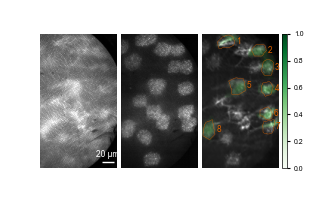

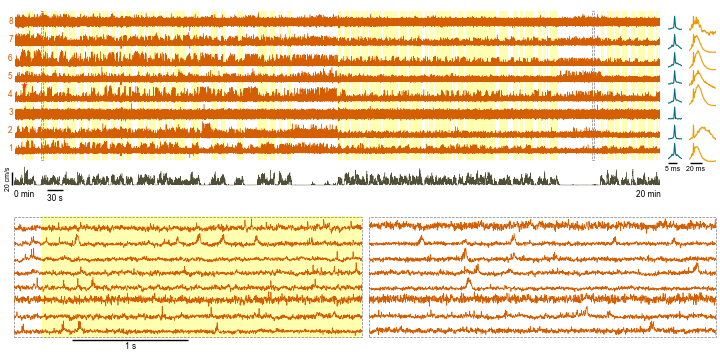

In [44]:
# Split layout version: images and traces in separate figures
# This cell expects the main summary-figure cell above to have been run first.

import matplotlib as mpl

# Rebuild the image panel as a horizontal layout with each image rotated 90 degrees
fig_images = plt.figure(figsize=(3.2, 2.))
gs_images_split = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.08)
ax1_split = fig_images.add_subplot(gs_images_split[0, 0])
ax2_split = fig_images.add_subplot(gs_images_split[0, 1])
ax3_split = fig_images.add_subplot(gs_images_split[0, 2])
cax3_split = fig_images.add_subplot(gs_images_split[0, 3])

def _rot90_image(img):
    return np.rot90(img, k=1)

vmin_wf = np.percentile(WF_image, 0)
vmax_wf = np.percentile(WF_image, 99.5)
wf_image_rot = _rot90_image(WF_image)
ax1_split.imshow(wf_image_rot, cmap='gray', aspect='equal', vmin=vmin_wf, vmax=vmax_wf)
ax1_split.axis('off')

pixel_size_um = 0.59 * 2
scale_bar_um = 20
scale_bar_pixels = scale_bar_um / pixel_size_um
wf_height_rot, wf_width_rot = wf_image_rot.shape[:2]
scale_x_start = wf_width_rot * 0.8
scale_y = wf_height_rot * 0.95
ax1_split.plot([scale_x_start, scale_x_start + scale_bar_pixels], [scale_y, scale_y],
               color='white', linewidth=1, solid_capstyle='butt')
ax1_split.text(scale_x_start + scale_bar_pixels / 2, scale_y - wf_height_rot * 0.02, '20 μm',
               fontsize=6, ha='center', va='bottom', color='white')

mean_image1_rot = _rot90_image(mean_image1)
ax2_split.imshow(mean_image1_rot, cmap='gray', aspect='equal')
ax2_split.axis('off')

mean_image2_rot = _rot90_image(mean_image2)
ax3_split.imshow(mean_image2_rot, cmap='gray', aspect='equal')
if len(display_cell_indices) > 0:
    weights_overlay_split = np.nanmax(np.clip(weights[display_cell_indices], 0, None), axis=0)
else:
    weights_overlay_split = np.zeros(mean_image2.shape, dtype=float)
if np.nanmax(weights_overlay_split) > 0:
    weights_overlay_split = weights_overlay_split / np.nanpercentile(weights_overlay_split[weights_overlay_split > 0], 99)
    weights_overlay_split = np.clip(weights_overlay_split, 0, 1)
    weights_overlay_split = _rot90_image(weights_overlay_split)
    weights_rgba_split = np.zeros((*weights_overlay_split.shape, 4), dtype=float)
    weights_rgba_split[..., 1] = 0.9
    weights_rgba_split[..., 3] = 0.25 * weights_overlay_split
    ax3_split.imshow(weights_rgba_split, aspect='equal')
ax3_split.axis('off')

for display_idx, cell_idx in enumerate(display_cell_indices):
    roi_rot = _rot90_image(ROIs[cell_idx])
    ax3_split.contour(roi_rot, levels=[0.5], colors=[trace_color], linewidths=0.25)
    if np.nansum(roi_rot) <= 0:
        continue
    nonzero = np.where(roi_rot > 0)
    y_min_rot, y_max_rot = nonzero[0].min(), nonzero[0].max()
    x_max_rot = nonzero[1].max()
    text_x = x_max_rot + 2
    text_y = (y_min_rot + y_max_rot) // 2
    ax3_split.text(text_x, text_y, str(display_idx + 1), fontsize=6, color=trace_color,
                   ha='left', va='center', fontweight='normal')

mappable = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=1), cmap='Greens')
fig_images.canvas.draw()
ax3_pos = ax3_split.get_position()
cax_width = cax3_split.get_position().width
cax_pad = 0.01
cax3_split.set_position([ax3_pos.x1 + cax_pad, ax3_pos.y0, cax_width, ax3_pos.height])
colorbar = fig_images.colorbar(mappable, cax=cax3_split)
colorbar.ax.tick_params(labelsize=5, length=2)

output_images_path = os.path.join(main_data_folder, 'neural_data_summary_figure_v5_images.svg')
fig_images.savefig(output_images_path, dpi=300, bbox_inches='tight')
print(f'Image-panel figure saved to {os.path.abspath(output_images_path)}')

# Build a trace-focused figure: full traces + spike shapes on top, zoom panels below
fig_traces = plt.figure(figsize=(7.2, 3.6))
gs_traces = gridspec.GridSpec(
    2, 16,
    height_ratios=[2.0, 1.25],
    width_ratios=[1] * 14 + [0.35, 0.7],
    hspace=0.08, wspace=0.2
)

ax_full = fig_traces.add_subplot(gs_traces[0, :14])
ax_ss_split = fig_traces.add_subplot(gs_traces[0, 14])
ax_cb_split = fig_traces.add_subplot(gs_traces[0, 15], sharey=ax_ss_split)

gs_zoom_split = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_traces[1, :], wspace=0.02)
ax_zoom1 = fig_traces.add_subplot(gs_zoom_split[0, 0])
ax_zoom2 = fig_traces.add_subplot(gs_zoom_split[0, 1])

box_y_min = -0.1
box_y_max = num_cells + 0.1
box_height = box_y_max - box_y_min
speed_y_offset = -1.5

for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    ax_full.add_patch(Rectangle((t_start, box_y_min), t_end - t_start, box_height,
                                facecolor='yellow', alpha=0.3, edgecolor='none', zorder=0))

for display_idx, trace_norm in enumerate(norm_traces):
    cell_idx = display_cell_indices[display_idx]
    ax_full.plot(time_axis, trace_norm + display_idx, linewidth=0.3, color=trace_color, rasterized=True, zorder=2)
    _shade_bad_mask_segments(ax_full, display_idx, cell_idx)
    _plot_plateau_stars(ax_full, display_idx, cell_idx)
    ax_full.text(time_axis[0] - 3, display_idx + 0.5, f'{display_idx + 1}',
                 fontsize=6, ha='right', va='center', color=trace_color)

speed_time = np.arange(len(speed_smooth)) / frame_rate
speed_max = np.nanmax(speed_smooth)
speed_normalized = speed_smooth / speed_max
ax_full.plot(speed_time, speed_normalized + speed_y_offset, linewidth=0.3, color='#524F38', rasterized=True)

speed_scale_value = 20
speed_scale_height = speed_scale_value / speed_max
vscale_x = time_axis[0] - 5
vscale_y_bottom = speed_y_offset
vscale_y_top = speed_y_offset + speed_scale_height
ax_full.plot([vscale_x, vscale_x], [vscale_y_bottom, vscale_y_top],
             color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax_full.text(vscale_x - 2, (vscale_y_bottom + vscale_y_top) / 2, f'{speed_scale_value} cm/s',
             fontsize=5, ha='right', va='center', rotation=90, color='black')

start_time_min = int(round(time_axis[0] / 60))
end_time_min = int(round(time_axis[-1] / 60))
ax_full.text(time_axis[0], speed_y_offset - 0.3, f'{start_time_min} min', fontsize=6, ha='left', va='top')
ax_full.text(time_axis[-1], speed_y_offset - 0.3, f'{end_time_min} min', fontsize=6, ha='right', va='top')

time_range = time_axis[-1] - time_axis[0]
scale_bar_length = 30
x_scale_start = time_axis[0] + time_range * 0.05
x_scale_end = x_scale_start + scale_bar_length
y_scale = speed_y_offset - 0.3
ax_full.plot([x_scale_start, x_scale_end], [y_scale, y_scale],
             color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax_full.text((x_scale_start + x_scale_end) / 2, y_scale - 0.2, '30 s',
             fontsize=6, ha='center', va='top')

ax_full.add_patch(Rectangle((zoom1_start, box_y_min), zoom_window, box_height,
                            linewidth=0.5, edgecolor='gray', facecolor='none',
                            linestyle='--', clip_on=False))
ax_full.add_patch(Rectangle((zoom2_start, box_y_min), zoom_window, box_height,
                            linewidth=0.5, edgecolor='gray', facecolor='none',
                            linestyle='--', clip_on=False))

ax_full.set_xlim(time_axis[0], time_axis[-1])
ax_full.set_ylim(speed_y_offset - 1, num_cells + 0.3)
ax_full.axis('off')

ax_ss_split.set_xlim(-ss_pre_ms, ss_post_ms)
ax_ss_split.set_ylim(speed_y_offset - 1, num_cells + 0.3)
ax_ss_split.axis('off')
ax_cb_split.set_xlim(-cb_pre_ms, cb_post_ms)
ax_cb_split.set_ylim(speed_y_offset - 1, num_cells + 0.3)
ax_cb_split.axis('off')

ss_waveform_t = np.linspace(-ss_pre_ms, ss_post_ms, ss_pre_samp + ss_post_samp + 1)
cb_waveform_t = np.linspace(-cb_pre_ms, cb_post_ms, cb_pre_samp + cb_post_samp + 1)

for display_idx, cell_idx in enumerate(display_cell_indices):
    trace = traces[cell_idx].squeeze()
    ss_idx = _get_simple_spike_indices(cell_idx)
    ss_shape, ss_count = _mean_spike_shape_v5(trace, ss_idx, ss_pre_samp, ss_post_samp)
    cb_idx = _get_burst_first_spike_indices(cell_idx)
    cb_shape, cb_count = _mean_spike_shape_v5(trace, cb_idx, cb_pre_samp, cb_post_samp)
    if ss_shape is not None and ss_count >= min_spikes_for_plot:
        ax_ss_split.plot(ss_waveform_t, ss_shape * waveform_scale + display_idx, color=simple_color,
                         linewidth=waveform_linewidth)
    if cb_shape is not None and cb_count >= min_spikes_for_plot:
        ax_cb_split.plot(cb_waveform_t, cb_shape * waveform_scale + display_idx, color=complex_color,
                         linewidth=waveform_linewidth)

bar_y = -0.3
ss_scale_bar_ms = 20
ss_bar_x_start = -ss_pre_ms + 1
ss_bar_x_end = ss_bar_x_start + ss_scale_bar_ms
ax_ss_split.plot([ss_bar_x_start, ss_bar_x_end], [bar_y, bar_y], color='black', linewidth=1,
                 solid_capstyle='butt', clip_on=False)
ax_ss_split.text((ss_bar_x_start + ss_bar_x_end) / 2, bar_y - 0.15, '5 ms', fontsize=5, ha='center', va='top')

cb_scale_bar_ms = 50
cb_bar_x_start = -cb_pre_ms + 5
cb_bar_x_end = cb_bar_x_start + cb_scale_bar_ms
ax_cb_split.plot([cb_bar_x_start, cb_bar_x_end], [bar_y, bar_y], color='black', linewidth=1,
                 solid_capstyle='butt', clip_on=False)
ax_cb_split.text((cb_bar_x_start + cb_bar_x_end) / 2, bar_y - 0.15, '20 ms', fontsize=5, ha='center', va='top')

zoom1_end = zoom1_start + zoom_window
for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    if t_end >= zoom1_start and t_start <= zoom1_end:
        ax_zoom1.axvspan(max(t_start, zoom1_start), min(t_end, zoom1_end), color='yellow', alpha=0.3, zorder=0)

zoom1_idx_start = int(zoom1_start * sampling_rate)
zoom1_idx_end = int(zoom1_end * sampling_rate)
for display_idx, cell_idx in enumerate(display_cell_indices):
    trace = traces[cell_idx].squeeze().copy()
    trace[:1000] = np.nan
    segment = trace[zoom1_idx_start:zoom1_idx_end]
    seg_min = np.nanmin(segment)
    seg_max = np.nanmax(segment)
    if np.isnan(seg_min) or np.isnan(seg_max) or (seg_max == seg_min):
        trace_norm = np.full_like(trace, np.nan)
    else:
        trace_norm = (trace - seg_min) / (seg_max - seg_min)
    ax_zoom1.plot(time_axis, trace_norm + display_idx, linewidth=0.5, color=trace_color, rasterized=True, zorder=2)
    _shade_bad_mask_segments(ax_zoom1, display_idx, cell_idx, zoom1_start, zoom1_end)
    _shade_plateau_segments(ax_zoom1, display_idx, cell_idx, zoom1_start, zoom1_end)
ax_zoom1.set_xlim(zoom1_start, zoom1_end)
ax_zoom1.set_ylim(-0.2, num_cells + 0.2)
ax_zoom1.axis('off')

scale_bar_1s = 1
scale_x_start_zoom = zoom1_start + 0.5
scale_y_zoom = -0.3
ax_zoom1.plot([scale_x_start_zoom, scale_x_start_zoom + scale_bar_1s], [scale_y_zoom, scale_y_zoom],
              color='black', linewidth=1, solid_capstyle='butt', clip_on=False)
ax_zoom1.text(scale_x_start_zoom + scale_bar_1s / 2, scale_y_zoom - 0.15, '1 s',
              fontsize=6, ha='center', va='top')
rect_zoom1 = Rectangle((zoom1_start, -0.1), zoom_window, num_cells + 0.2,
                       linewidth=0.5, edgecolor='gray', facecolor='none', linestyle='--', clip_on=False)
ax_zoom1.add_patch(rect_zoom1)

zoom2_end = zoom2_start + zoom_window
for start, end in moving_epochs:
    t_start = start / frame_rate
    t_end = end / frame_rate
    if t_end >= zoom2_start and t_start <= zoom2_end:
        ax_zoom2.axvspan(max(t_start, zoom2_start), min(t_end, zoom2_end), color='yellow', alpha=0.3, zorder=0)

zoom2_idx_start = int(zoom2_start * sampling_rate)
zoom2_idx_end = int(zoom2_end * sampling_rate)
for display_idx, cell_idx in enumerate(display_cell_indices):
    trace = traces[cell_idx].squeeze().copy()
    trace[:1000] = np.nan
    segment = trace[zoom2_idx_start:zoom2_idx_end]
    seg_min = np.nanmin(segment)
    seg_max = np.nanmax(segment)
    if np.isnan(seg_min) or np.isnan(seg_max) or (seg_max == seg_min):
        trace_norm = np.full_like(trace, np.nan)
    else:
        trace_norm = (trace - seg_min) / (seg_max - seg_min)
    ax_zoom2.plot(time_axis, trace_norm + display_idx, linewidth=0.5, color=trace_color, rasterized=True, zorder=2)
    _shade_bad_mask_segments(ax_zoom2, display_idx, cell_idx, zoom2_start, zoom2_end)
    _shade_plateau_segments(ax_zoom2, display_idx, cell_idx, zoom2_start, zoom2_end)
ax_zoom2.set_xlim(zoom2_start, zoom2_end)
ax_zoom2.set_ylim(-0.2, num_cells + 0.2)
ax_zoom2.axis('off')
rect_zoom2 = Rectangle((zoom2_start, -0.1), zoom_window, num_cells + 0.2,
                       linewidth=0.5, edgecolor='gray', facecolor='none', linestyle='--', clip_on=False)
ax_zoom2.add_patch(rect_zoom2)

fig_traces.subplots_adjust(left=0.02, right=0.995, top=0.98, bottom=0.06)
output_traces_path = os.path.join(main_data_folder, 'neural_data_summary_figure_v5_traces.svg')
fig_traces.savefig(output_traces_path, dpi=300)
print(f'Trace-panel figure saved to {os.path.abspath(output_traces_path)}')


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/trace_with_spikes_cell6.svg
SS in window: 5, CS in window: 4


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_34549/2655876731.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


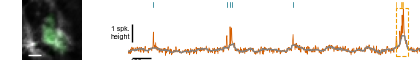

In [43]:
t1 = 41.6
t2 = t1 + 1.5
cell_idx = 5  # 0 based

complex_color = '#EE9B00'  # orange for complex bursts
simple_color = '#026C80'   # teal for simple spikes
plateau_color = '#FF2D2D'  # bright red for plateaus
trace_color = '#D55E00'

weights = weights_all[0]
ROIs = ROIs_all[0]
roi = np.asarray(ROIs[cell_idx], dtype=bool)
cell_weights = np.clip(np.asarray(weights[cell_idx], dtype=float), 0, None)

# Create figure with cropped ROI panel on the left and trace panel on the right
fig, (ax_img, ax) = plt.subplots(
    1, 2, figsize=(4.2, 0.6),
    gridspec_kw={'width_ratios': [1.0, 2.8], 'wspace': 0.12}
)

sampling_rate = 500
time_axis = np.arange(traces.shape[1]) / sampling_rate

# Crop around the selected cell so its contour and green mask stay visible
support_mask = roi.copy()
if np.any(cell_weights > 0):
    weight_threshold = 0.05 * np.nanmax(cell_weights)
    support_mask |= cell_weights >= weight_threshold
yy, xx = np.where(support_mask)
crop_pad = 8
if yy.size == 0 or xx.size == 0:
    yy, xx = np.where(roi)
y0 = max(0, int(yy.min()) - crop_pad)
y1 = min(mean_image2.shape[0], int(yy.max()) + crop_pad + 1)
x0 = max(0, int(xx.min()) - crop_pad)
x1 = min(mean_image2.shape[1], int(xx.max()) + crop_pad + 1)

ax_img.imshow(mean_image2[y0:y1, x0:x1], cmap='gray', aspect='equal')
weights_crop = cell_weights[y0:y1, x0:x1]
if np.any(weights_crop > 0):
    weights_norm = weights_crop / np.nanpercentile(weights_crop[weights_crop > 0], 99)
    weights_norm = np.clip(weights_norm, 0, 1)
    weights_rgba = np.zeros((*weights_norm.shape, 4), dtype=float)
    weights_rgba[..., 1] = 0.9
    weights_rgba[..., 3] = 0.35 * weights_norm
    ax_img.imshow(weights_rgba, aspect='equal')
pixel_size_um = 0.59 * 2
scale_bar_um = 10
scale_bar_pixels = scale_bar_um / pixel_size_um
crop_height, crop_width = y1 - y0, x1 - x0
scale_x_start = crop_width * 0.08
scale_y = crop_height * 0.9
ax_img.plot([scale_x_start, scale_x_start + scale_bar_pixels], [scale_y, scale_y],
            color='white', linewidth=1, solid_capstyle='butt')
ax_img.axis('off')

# Get trace (no normalization)
trace = traces_SNR_interpolated[cell_idx].squeeze().copy()
trace[:1000] = np.nan

zoom_idx_start = int(t1 * sampling_rate)
zoom_idx_end = int(t2 * sampling_rate)

# Get Vm (no normalization)
vm = Vm_SNR_interpolated[cell_idx].squeeze().copy()
vm[:1000] = np.nan

# Plot Vm in light gray (behind)
ax.plot(time_axis, vm, linewidth=1, color='gray', zorder=2)

# Plot trace in orange (on top)
ax.plot(time_axis, trace, linewidth=0.5, color=trace_color, zorder=1)

# Get simple spikes and complex spikes for this cell
ss_indices = refined_SS[cell_idx] if refined_SS[cell_idx] is not None else []
cs_indices = all_CS_spikes[cell_idx] if all_CS_spikes[cell_idx] is not None else []

# Convert to arrays
ss_indices = np.asarray(ss_indices, dtype=int) if len(ss_indices) > 0 else np.array([], dtype=int)
cs_indices = np.asarray(cs_indices, dtype=int) if len(cs_indices) > 0 else np.array([], dtype=int)

# Filter spikes within zoom window
ss_in_window = ss_indices[(ss_indices >= zoom_idx_start) & (ss_indices < zoom_idx_end)]
cs_in_window = cs_indices[(cs_indices >= zoom_idx_start) & (cs_indices < zoom_idx_end)]

# Convert to time
ss_times = ss_in_window / sampling_rate
cs_times = cs_in_window / sampling_rate

# Get complex burst and plateau intervals for this cell
burst_dict = complex_bursts_dicts[cell_idx] if complex_bursts_dicts is not None and cell_idx < len(complex_bursts_dicts) else None
plateau_dict = plateaus_dicts[cell_idx] if plateaus_dicts is not None and cell_idx < len(plateaus_dicts) else None
burst_starts = np.asarray(burst_dict.get('starts', []), dtype=int) if burst_dict is not None else np.array([], dtype=int)
burst_ends = np.asarray(burst_dict.get('ends', []), dtype=int) if burst_dict is not None else np.array([], dtype=int)
plateau_starts = np.asarray(plateau_dict.get('starts', []), dtype=int) if plateau_dict is not None else np.array([], dtype=int)
plateau_ends = np.asarray(plateau_dict.get('ends', []), dtype=int) if plateau_dict is not None else np.array([], dtype=int)

# Compute y limits from data in zoom window
trace_segment = trace[zoom_idx_start:zoom_idx_end]
vm_segment = vm[zoom_idx_start:zoom_idx_end]
y_min = np.nanmin([np.nanmin(trace_segment), np.nanmin(vm_segment)])
y_max = np.nanmax([np.nanmax(trace_segment), np.nanmax(vm_segment)])
y_range = y_max - y_min
y_pad = 0.1 * y_range

# Plot rasters on top of trace
raster_y_bottom = y_max + 0.05 * y_range
raster_y_top = y_max + 0.15 * y_range

# Simple spikes
for t in ss_times:
    ax.plot([t, t], [raster_y_bottom, raster_y_top], color=simple_color, linewidth=0.5, zorder=3)

# Complex spikes
for t in cs_times:
    ax.plot([t, t], [raster_y_bottom, raster_y_top], color=complex_color, linewidth=0.5, zorder=3)

# Add dashed boxes around complex bursts and plateaus
box_y = y_min - 0.02 * y_range
box_height = (y_max - y_min) + 0.04 * y_range
for start_idx, end_idx in zip(burst_starts, burst_ends):
    start_t = max(start_idx / sampling_rate, t1)
    end_t = min((end_idx + 1) / sampling_rate, t2)
    if end_t > start_t:
        ax.add_patch(Rectangle(
            (start_t, box_y), end_t - start_t, box_height,
            linewidth=0.8, edgecolor=complex_color, facecolor='none',
            linestyle='--', zorder=4
        ))
for start_idx, end_idx in zip(plateau_starts, plateau_ends):
    start_t = max(start_idx / sampling_rate, t1)
    end_t = min((end_idx + 1) / sampling_rate, t2)
    if end_t > start_t:
        ax.add_patch(Rectangle(
            (start_t, box_y), end_t - start_t, box_height,
            linewidth=0.8, edgecolor=plateau_color, facecolor='none',
            linestyle='--', zorder=4
        ))

# Set limits and remove axes
ax.set_xlim(t1, t2)
ax.set_ylim(y_min - y_pad, raster_y_top + 0.05 * y_range)
ax.axis('off')

# Add horizontal scale bar (100 ms)
scale_bar_100ms = 0.1
scale_x_start = t1 + 0.02
scale_x_end = scale_x_start + scale_bar_100ms
scale_y = y_min - 0.5 * y_pad
ax.plot([scale_x_start, scale_x_end], [scale_y, scale_y],
        color='black', linewidth=1., solid_capstyle='butt', clip_on=False)
ax.text((scale_x_start + scale_x_end) / 2, scale_y - 0.3 * y_pad, '100 ms',
        fontsize=5, ha='center', va='top')

# Add vertical scale bar (length 1 = 1 spike height)
vscale_x = t1 + 0.02
vscale_y_bottom = scale_y
vscale_y_top = scale_y + 1
ax.plot([vscale_x, vscale_x], np.array([vscale_y_bottom, vscale_y_top]) + 0.9,
        color='black', linewidth=1., solid_capstyle='butt', clip_on=False)
ax.text(vscale_x - 0.01, (vscale_y_bottom + vscale_y_top) / 2 + 0.9, '1 spk.\nheight',
        fontsize=5, ha='right', va='center')

plt.tight_layout()
plt.subplots_adjust(left=0.0, right=1.0, top=1, bottom=0)

# Save figure
output_figure_path = os.path.join(main_data_folder, f'trace_with_spikes_cell{cell_idx+1}.svg')
fig.savefig(output_figure_path, dpi=300)
print(f'Saved: {os.path.abspath(output_figure_path)}')
print(f'SS in window: {len(ss_in_window)}, CS in window: {len(cs_in_window)}')

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/trace_with_spikes_cell4.svg
SS in window: 2, CS in window: 14


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_34549/1142609590.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


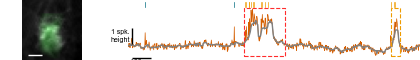

In [49]:
t1 = 16.3
t2 = t1 + 1.5
cell_idx = 3  # 0 based

complex_color = '#EE9B00'  # orange for complex bursts
simple_color = '#026C80'   # teal for simple spikes
plateau_color = '#FF2D2D'  # bright red for plateaus
trace_color = '#D55E00'

weights = weights_all[0]
ROIs = ROIs_all[0]
roi = np.asarray(ROIs[cell_idx], dtype=bool)
cell_weights = np.clip(np.asarray(weights[cell_idx], dtype=float), 0, None)

# Create figure with cropped ROI panel on the left and trace panel on the right
fig, (ax_img, ax) = plt.subplots(
    1, 2, figsize=(4.2, 0.6),
    gridspec_kw={'width_ratios': [1.0, 2.8], 'wspace': 0.12}
)

sampling_rate = 500
time_axis = np.arange(traces.shape[1]) / sampling_rate

# Crop around the selected cell so its contour and green mask stay visible
support_mask = roi.copy()
if np.any(cell_weights > 0):
    weight_threshold = 0.05 * np.nanmax(cell_weights)
    support_mask |= cell_weights >= weight_threshold
yy, xx = np.where(support_mask)
crop_pad = 8
if yy.size == 0 or xx.size == 0:
    yy, xx = np.where(roi)
y0 = max(0, int(yy.min()) - crop_pad)
y1 = min(mean_image2.shape[0], int(yy.max()) + crop_pad + 1)
x0 = max(0, int(xx.min()) - crop_pad)
x1 = min(mean_image2.shape[1], int(xx.max()) + crop_pad + 1)

ax_img.imshow(mean_image2[y0:y1, x0:x1], cmap='gray', aspect='equal')
weights_crop = cell_weights[y0:y1, x0:x1]
if np.any(weights_crop > 0):
    weights_norm = weights_crop / np.nanpercentile(weights_crop[weights_crop > 0], 99)
    weights_norm = np.clip(weights_norm, 0, 1)
    weights_rgba = np.zeros((*weights_norm.shape, 4), dtype=float)
    weights_rgba[..., 1] = 0.9
    weights_rgba[..., 3] = 0.35 * weights_norm
    ax_img.imshow(weights_rgba, aspect='equal')
pixel_size_um = 0.59 * 2
scale_bar_um = 10
scale_bar_pixels = scale_bar_um / pixel_size_um
crop_height, crop_width = y1 - y0, x1 - x0
scale_x_start = crop_width * 0.08
scale_y = crop_height * 0.9
ax_img.plot([scale_x_start, scale_x_start + scale_bar_pixels], [scale_y, scale_y],
            color='white', linewidth=1, solid_capstyle='butt')
ax_img.axis('off')

# Get trace (no normalization)
trace = traces_SNR_interpolated[cell_idx].squeeze().copy()
trace[:1000] = np.nan

zoom_idx_start = int(t1 * sampling_rate)
zoom_idx_end = int(t2 * sampling_rate)

# Get Vm (no normalization)
vm = Vm_SNR_interpolated[cell_idx].squeeze().copy()
vm[:1000] = np.nan

# Plot Vm in light gray (behind)
ax.plot(time_axis, vm, linewidth=1, color='gray', zorder=2)

# Plot trace in orange (on top)
ax.plot(time_axis, trace, linewidth=0.5, color=trace_color, zorder=1)

# Get simple spikes and complex spikes for this cell
ss_indices = refined_SS[cell_idx] if refined_SS[cell_idx] is not None else []
cs_indices = all_CS_spikes[cell_idx] if all_CS_spikes[cell_idx] is not None else []

# Convert to arrays
ss_indices = np.asarray(ss_indices, dtype=int) if len(ss_indices) > 0 else np.array([], dtype=int)
cs_indices = np.asarray(cs_indices, dtype=int) if len(cs_indices) > 0 else np.array([], dtype=int)

# Filter spikes within zoom window
ss_in_window = ss_indices[(ss_indices >= zoom_idx_start) & (ss_indices < zoom_idx_end)]
cs_in_window = cs_indices[(cs_indices >= zoom_idx_start) & (cs_indices < zoom_idx_end)]

# Convert to time
ss_times = ss_in_window / sampling_rate
cs_times = cs_in_window / sampling_rate

# Get complex burst and plateau intervals for this cell
burst_dict = complex_bursts_dicts[cell_idx] if complex_bursts_dicts is not None and cell_idx < len(complex_bursts_dicts) else None
plateau_dict = plateaus_dicts[cell_idx] if plateaus_dicts is not None and cell_idx < len(plateaus_dicts) else None
burst_starts = np.asarray(burst_dict.get('starts', []), dtype=int) if burst_dict is not None else np.array([], dtype=int)
burst_ends = np.asarray(burst_dict.get('ends', []), dtype=int) if burst_dict is not None else np.array([], dtype=int)
plateau_starts = np.asarray(plateau_dict.get('starts', []), dtype=int) if plateau_dict is not None else np.array([], dtype=int)
plateau_ends = np.asarray(plateau_dict.get('ends', []), dtype=int) if plateau_dict is not None else np.array([], dtype=int)

# Compute y limits from data in zoom window
trace_segment = trace[zoom_idx_start:zoom_idx_end]
vm_segment = vm[zoom_idx_start:zoom_idx_end]
y_min = np.nanmin([np.nanmin(trace_segment), np.nanmin(vm_segment)])
y_max = np.nanmax([np.nanmax(trace_segment), np.nanmax(vm_segment)])
y_range = y_max - y_min
y_pad = 0.1 * y_range

# Plot rasters on top of trace
raster_y_bottom = y_max + 0.05 * y_range
raster_y_top = y_max + 0.15 * y_range

# Simple spikes
for t in ss_times:
    ax.plot([t, t], [raster_y_bottom, raster_y_top], color=simple_color, linewidth=0.5, zorder=3)

# Complex spikes
for t in cs_times:
    ax.plot([t, t], [raster_y_bottom, raster_y_top], color=complex_color, linewidth=0.5, zorder=3)

# Add dashed boxes around complex bursts and plateaus
box_y = y_min - 0.02 * y_range
box_height = (y_max - y_min) + 0.04 * y_range
for start_idx, end_idx in zip(burst_starts, burst_ends):
    start_t = max(start_idx / sampling_rate, t1)
    end_t = min((end_idx + 1) / sampling_rate, t2)
    if end_t > start_t:
        ax.add_patch(Rectangle(
            (start_t, box_y), end_t - start_t, box_height,
            linewidth=0.8, edgecolor=complex_color, facecolor='none',
            linestyle='--', zorder=4
        ))
for start_idx, end_idx in zip(plateau_starts, plateau_ends):
    start_t = max(start_idx / sampling_rate, t1)
    end_t = min((end_idx + 1) / sampling_rate, t2)
    if end_t > start_t:
        ax.add_patch(Rectangle(
            (start_t, box_y), end_t - start_t, box_height,
            linewidth=0.8, edgecolor=plateau_color, facecolor='none',
            linestyle='--', zorder=4
        ))

# Set limits and remove axes
ax.set_xlim(t1, t2)
ax.set_ylim(y_min - y_pad, raster_y_top + 0.05 * y_range)
ax.axis('off')

# Add horizontal scale bar (100 ms)
scale_bar_100ms = 0.1
scale_x_start = t1 + 0.02
scale_x_end = scale_x_start + scale_bar_100ms
scale_y = y_min - 0.5 * y_pad
ax.plot([scale_x_start, scale_x_end], [scale_y, scale_y],
        color='black', linewidth=1., solid_capstyle='butt', clip_on=False)
ax.text((scale_x_start + scale_x_end) / 2, scale_y - 0.3 * y_pad, '100 ms',
        fontsize=5, ha='center', va='top')

# Add vertical scale bar (length 1 = 1 spike height)
vscale_x = t1 + 0.02
vscale_y_bottom = scale_y
vscale_y_top = scale_y + 1
ax.plot([vscale_x, vscale_x], np.array([vscale_y_bottom, vscale_y_top]) + 0.9,
        color='black', linewidth=1., solid_capstyle='butt', clip_on=False)
ax.text(vscale_x - 0.01, (vscale_y_bottom + vscale_y_top) / 2 + 0.9, '1 spk.\nheight',
        fontsize=5, ha='right', va='center')

plt.tight_layout()
plt.subplots_adjust(left=0.0, right=1.0, top=1, bottom=0)

# Save figure
output_figure_path = os.path.join(main_data_folder, f'trace_with_spikes_cell{cell_idx+1}.svg')
fig.savefig(output_figure_path, dpi=300)
print(f'Saved: {os.path.abspath(output_figure_path)}')
print(f'SS in window: {len(ss_in_window)}, CS in window: {len(cs_in_window)}')